# 社會網絡分析與地理應用 第十三週作業

資訊工程學系 三年級 吳佳泰 S1254059

In [6]:
from tqdm import tqdm
from PIL import Image

import numpy as np
import numpy.random as rnd

from matplotlib.patches import Patch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import matplotlib.cm as cmx

import networkx as nx
import geopandas as gpd
import pandas as pd

import math
import os
import shutil

os.makedirs("homework_w12_picture", exist_ok=True)

def get_color(graph):
    color_dict = dict({'S':"green", "I":"red", 'R':'blue'})
    color = list(dict(graph.nodes(data="state")).values())
    color = [color_dict[i] for i in color]
    return color

def makeGif(sir, times, filename="sir_spread"):
    os.makedirs("homework_w13_picture/frames", exist_ok=True)

    for i in tqdm(range(times), desc="Generating GIF"):
        fig, ax = plt.subplots()    
        network = sir.networks[i]
        color = get_color(network)
        pos = nx.spring_layout(sir.networks[0], seed=42)

        nx.draw(network, pos, node_color=color, width=1, alpha=0.4, with_labels=True)
        
        ax.set_title("Time " + str(i))
        plt.savefig("homework_w13_picture/frames/time" + str(i) + ".png", bbox_inches='tight')
        plt.close()

    frames = [Image.open(f'homework_w13_picture/frames/time{i}.png') for i in range(times)]
    frames[0].save("homework_w13_picture/" + filename + ".gif", save_all=True, append_images=frames[1:], duration=200, loop=0)

    shutil.rmtree("homework_w13_picture/frames")
    print(filename + ".gif is saved successfully")




## 請根據individual_level實作的範例，回答以下問題

### 1. 假設空手道俱樂部的網絡當中，編號19的成員為起始感染者，請模擬50個時間點以後的疾病擴散狀況（時間序列圖）。
> **hint**: 需要修改起始感染設定的程式碼

Generating GIF:   0%|          | 0/50 [00:00<?, ?it/s]

Generating GIF: 100%|██████████| 50/50 [00:16<00:00,  2.95it/s]


Q1_SIR_spread.gif is saved successfully


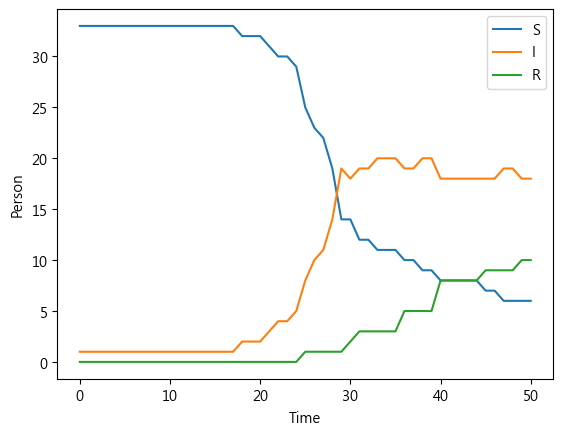

In [7]:
class SIRnetwork:
    def __init__(self, graph, pInfect, pRecover):
        self.pInfect = pInfect
        self.pRecover = pRecover
        self.graph = graph
        self.reset()
        
    def reset(self):
        for i in self.graph.nodes.keys():
            self.graph.nodes[i]["state"] = "S"

    def create_source(self, no):
        self.graph.nodes[no]["state"] = "I"

    def model(self):
        infected_people = [n for n, d in self.graph.nodes(data=True) if (d.get('state') == "I")]  

        for i in infected_people:
            for m in self.graph.neighbors(i):
                if (self.graph.nodes[m]["state"] == "S"):
                    if (rnd.random() <= self.pInfect):
                        self.graph.nodes[m]["state"] = "I"

            if (rnd.random() <= self.pRecover):
                self.graph.nodes[i]["state"] = "R"

    def spreading_run(self, times):
        self.susceptible = []
        self.infected = []
        self.recovered = []
        self.networks = []

        self.susceptible.append(sum(1 for _, d in self.graph.nodes(data=True) if (d.get("state") == "S")))
        self.infected.append(sum(1 for _, d in self.graph.nodes(data=True) if (d.get("state") == "I")))
        self.recovered.append(sum(1 for _, d in self.graph.nodes(data=True) if (d.get("state") == "R")))
        self.networks.append(self.graph.copy())
            
        for time in range(times):
            self.model() 
            
            susceptible = [n for n, d in self.graph.nodes(data=True) if (d.get("state") == "S")]
            self.susceptible.append(len(susceptible))                                                           
                
            infected = [n for n, d in self.graph.nodes(data=True) if (d.get("state") == "I")]      
            self.infected.append(len(infected))                                                                
            
            recovered = [n for n, d in self.graph.nodes(data=True) if (d.get("state") == "R")]   
            self.recovered.append(len(recovered))                                                               
            
            self.networks.append(self.graph.copy())                                                              


g1 = nx.karate_club_graph()

sir1 = SIRnetwork(g1, 0.05, 0.05) 
sir1.create_source(19)
sir1.spreading_run(50)  

plt.plot(sir1.susceptible, label="S")
plt.plot(sir1.infected, label="I")
plt.plot(sir1.recovered, label="R")

plt.legend()
plt.xlabel('Time')
plt.ylabel('Person')

makeGif(sir1, 50, "Q1_SIR_spread")

### 2. 呈上題，假設網絡中的連結權重代表兩個個體平均一周內碰面的天數，並且碰面次數愈多的個體之間，彼此傳播疾病的機率也愈大。請在編號9的成員為起始感染者的情境下，模擬50個時間點以後的疾病擴散狀況（時間序列圖）。

> **hint**: 需要額外修改擴散機制的程式碼

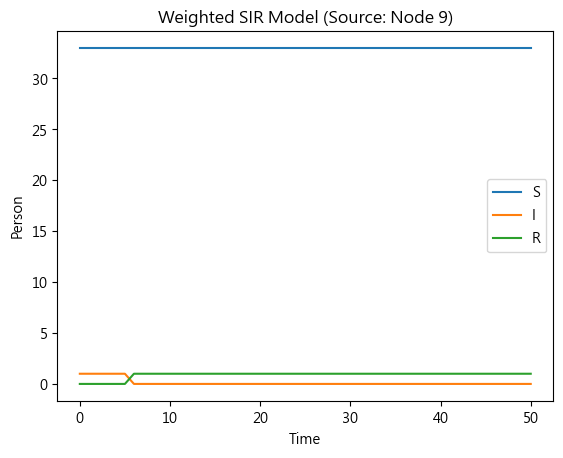

Generating GIF: 100%|██████████| 50/50 [00:15<00:00,  3.16it/s]


Q2_SIR_spread.gif is saved successfully


In [8]:
class SIRnetwork_weighted(SIRnetwork):   # 繼承第一題的 class
    def model(self):
        infected_people = [n for n, d in self.graph.nodes(data=True) if (d.get('state') == "I")]

        for i in infected_people:
            for m in self.graph.neighbors(i):
                if (self.graph.nodes[m]["state"] == "S"):
                    weight = self.graph[i][m].get("weight", 1)   
                    p = 1 - (1 - self.pInfect) ** weight

                    if (rnd.random() <= p):
                        self.graph.nodes[m]["state"] = "I"

            if (rnd.random() <= self.pRecover):
                self.graph.nodes[i]["state"] = "R"

g2 = nx.karate_club_graph()

for i, j in g2.edges():
    g2[i][j]["weight"] = rnd.randint(1, 7)

sir2 = SIRnetwork_weighted(g2, 0.05, 0.05)
sir2.create_source(9)        
sir2.spreading_run(50)

plt.plot(sir2.susceptible, label="S")
plt.plot(sir2.infected, label="I")
plt.plot(sir2.recovered, label="R")

plt.legend()
plt.xlabel('Time')
plt.ylabel('Person')
plt.title('Weighted SIR Model (Source: Node 9)')
plt.show()

makeGif(sir2, 50, "Q2_SIR_spread")


## 請根據population_level實作的範例，回答以下問題

### 3. 假設政府想進行北北基的封城模擬，定義了如表格中的3種嚴格程度，並且有相對應的人流剩餘比例。請模擬此3種不同的情境，然後以一張時間序列圖呈現3種情境的結果，並且說明3種情境的差異。

| | 原始人口剩餘比例 |
|:---:|:---:|
| 警戒 | 0.1 |
| 中等 | 0.5 |
| 預防 | 0.8 |

北北基交通區數量: 524 個
涵蓋縣市: ['臺北市' '新北市']
警戒 (0.1)  →  峰值感染人數:      6,852 人  (第 199 天)
中等 (0.5)  →  峰值感染人數:    739,346 人  (第 118 天)
預防 (0.8)  →  峰值感染人數:  1,482,884 人  (第 75 天)


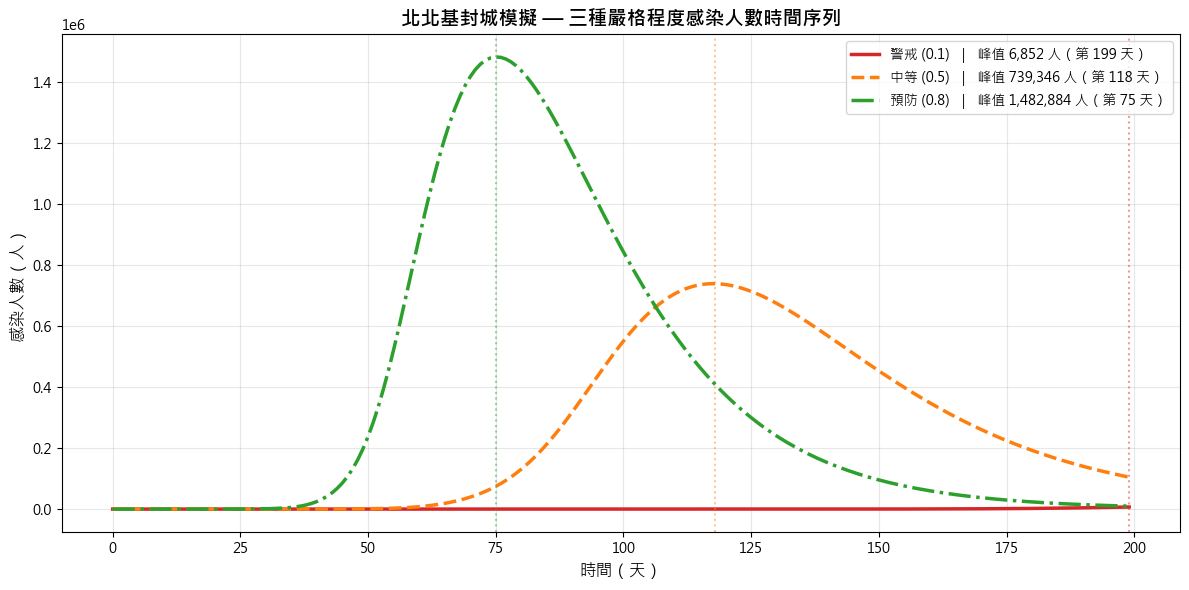

In [9]:
matplotlib.rcParams["font.family"] = "Microsoft JhengHei"
matplotlib.rcParams["axes.unicode_minus"] = False

class Geosir():
    def __init__(self, populationGDF, placeIDColumn, populationColumn, flowDF, idColumns, weightColumn, initInfection, duration=100, beta=0.17, gamma=0.0698):

        self.__populationGDF = populationGDF.copy()
        self.__populationGDF.sort_values(by=placeIDColumn, inplace=True)
        self.__populations = self.__populationGDF[populationColumn].values.astype(float)
        self.__placeIDs    = self.__populationGDF[placeIDColumn].values
        self.__placeCount  = len(self.__placeIDs)

        flowDiGraph = nx.from_pandas_edgelist(flowDF, source=idColumns[0], target=idColumns[1], edge_attr=weightColumn, create_using=nx.DiGraph())
        self.__odMatrix = nx.to_numpy_array(flowDiGraph, weight=weightColumn)
        self.__odMatrix = self.__odMatrix / self.__populations

        self.__S = self.__populations.copy()
        self.__I = np.zeros(self.__placeCount)
        self.__R = np.zeros(self.__placeCount)

        for key, val in initInfection.items():
            self.__S[key] -= val
            self.__I[key] += val

        self.__beta    = float(beta)
        self.__gamma   = float(gamma)
        self.__timeBar = list(range(int(duration) + 1))

    def model(self):
        n = len(self.__timeBar)
        self.__result = np.zeros((self.__placeCount, n * 3))

        for t in self.__timeBar:
            self.__result[:, t]       = self.__S
            self.__result[:, n + t]   = self.__I
            self.__result[:, n*2 + t] = self.__R

            proportion = self.__beta * self.__I / self.__populations
            Lambda     = proportion @ self.__odMatrix
            s2i = Lambda * self.__S
            i2r = self.__gamma * self.__I

            self.__S = np.maximum(self.__S - s2i, 0)
            self.__I = np.maximum(self.__I + s2i - i2r, 0)
            self.__R = np.maximum(self.__R + i2r, 0)

        cols = ([f'S{i}' for i in self.__timeBar] + [f'I{i}' for i in self.__timeBar] + [f'R{i}' for i in self.__timeBar])

        self.resultDF  = pd.DataFrame(self.__result, columns=cols)
        self.resultGDF = pd.merge(self.__populationGDF, self.resultDF.reset_index().rename(columns={"index": "_key"}), left_on="NewCode3", right_on="_key")
        self.resultGDF.crs = self.__populationGDF.crs

    def run(self):
        self.model()

dataFolder = r"homework_w13_data"
flowDF = pd.read_csv(os.path.join(dataFolder, 'edgelist.csv'))
tazGDF = gpd.read_file(os.path.join(dataFolder, 'tazone543.shp'), encoding='utf-8')

taz_sorted  = tazGDF.sort_values(by="NewCode3").reset_index(drop=True)
nnj_counties = ["臺北市", "新北市", "臺北縣", "基隆市"]
nnj_indices  = set(taz_sorted[taz_sorted["COUNTY"].isin(nnj_counties)].index.tolist())
print(f"北北基交通區數量: {len(nnj_indices)} 個")
print(f"涵蓋縣市: {taz_sorted[taz_sorted.index.isin(nnj_indices)]['COUNTY'].unique()}")

scenarios = {"警戒 (0.1)": 0.1, "中等 (0.5)": 0.5, "預防 (0.8)": 0.8}
duration  = 200
def apply_lockdown(flowDF, nnj_indices, ratio):
    """北北基相關人流乘以剩餘比例以模擬封城"""
    df   = flowDF.copy()
    mask = df['source'].isin(nnj_indices) | df['target'].isin(nnj_indices)
    df.loc[mask, 'weight'] *= ratio
    return df

results_I = {}
results_GDF = {}
for name, ratio in scenarios.items():
    modified_flow = apply_lockdown(flowDF, nnj_indices, ratio)
    solver = Geosir(tazGDF, 'NewCode3', 'RESIDENT', modified_flow,
                    idColumns=('source', 'target'), weightColumn='weight',
                    initInfection={127: 1}, duration=duration)
    solver.run()
    i_cols = [f'I{t}' for t in range(duration)]
    results_I[name] = solver.resultGDF[i_cols].values.sum(axis=0)
    peak_val = results_I[name].max()
    peak_day = results_I[name].argmax()
    print(f"{name}  →  峰值感染人數: {peak_val:>10,.0f} 人  (第 {peak_day} 天)")

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728', '#ff7f0e', '#2ca02c']
lines  = ['-', '--', '-.']

for (name, i_vals), color, ls in zip(results_I.items(), colors, lines):
    peak_val = i_vals.max()
    peak_day = i_vals.argmax()
    ax.plot(range(duration), i_vals, color=color, linestyle=ls, linewidth=2.5,
            label=f'{name}  ｜  峰值 {peak_val:,.0f} 人（第 {peak_day} 天）')
    ax.axvline(x=peak_day, color=color, linestyle=':', alpha=0.45)

ax.set_xlabel('時間（天）', fontsize=12)
ax.set_ylabel('感染人數（人）', fontsize=12)
ax.set_title('北北基封城模擬 — 三種嚴格程度感染人數時間序列', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4. 以地圖的方式比較3種情境的地理差異(加分選項)

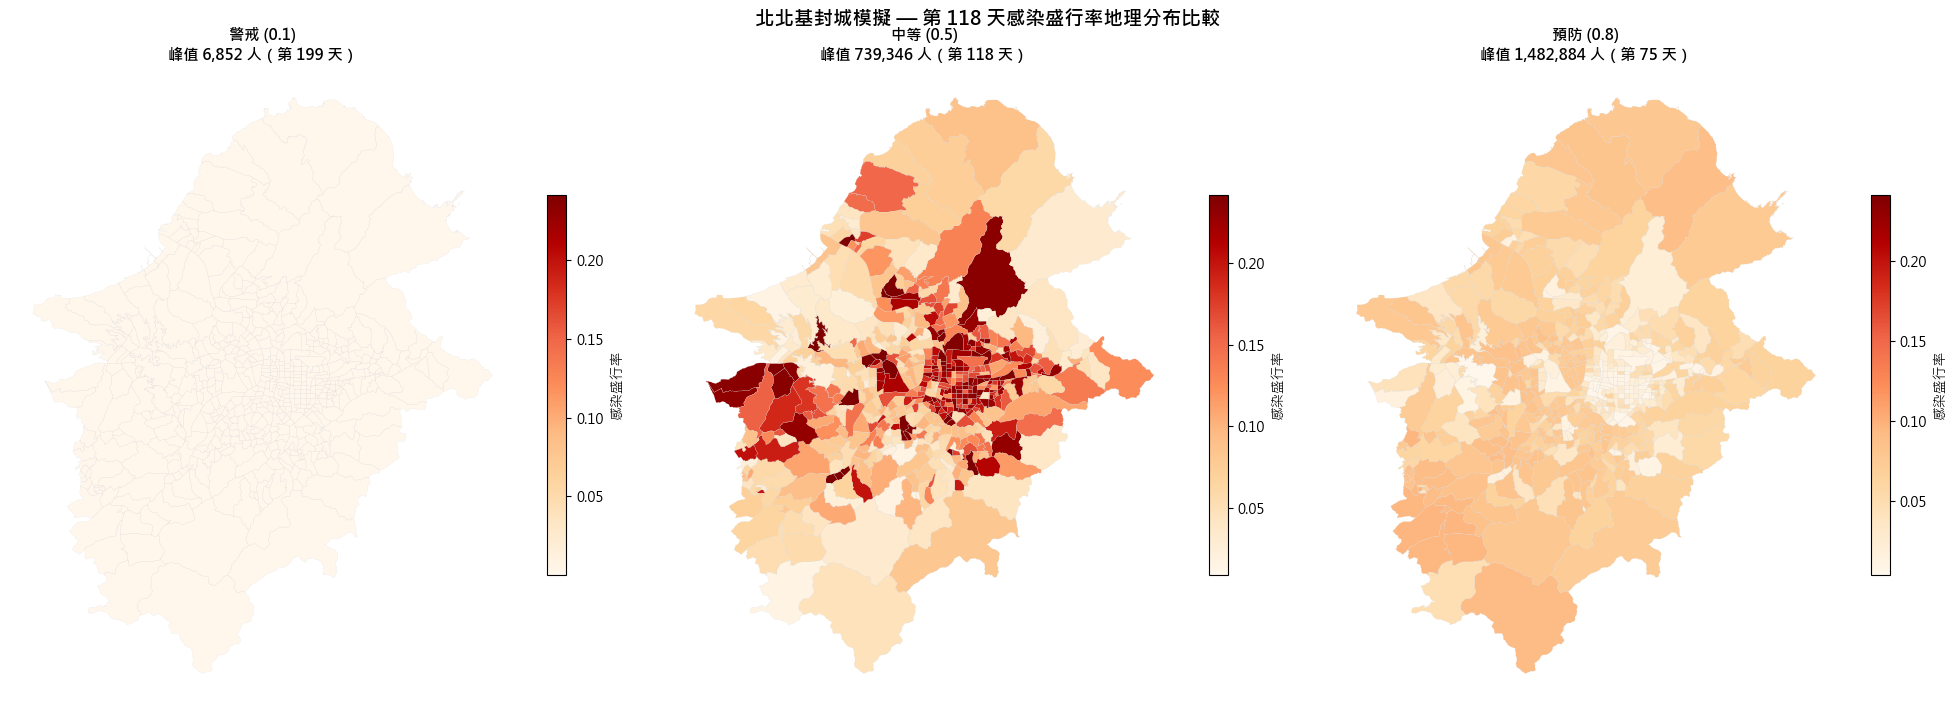

In [12]:
taz_sorted = tazGDF.sort_values(by='NewCode3').reset_index(drop=True)
nnj_counties = ['臺北市', '新北市', '臺北縣', '基隆市']
nnj_indices = set(taz_sorted[taz_sorted['COUNTY'].isin(nnj_counties)].index.tolist())

results_I = {}
results_GDF = {}
for name, ratio in scenarios.items():
    modified_flow = apply_lockdown(flowDF, nnj_indices, ratio)
    solver = Geosir(tazGDF, 'NewCode3', 'RESIDENT', modified_flow, idColumns=('source', 'target'), weightColumn='weight', initInfection={127:1}, duration=duration)
    solver.run()
    results_GDF[name] = solver.resultGDF
    i_cols = [f'I{i}' for i in range(duration)]
    results_I[name] = solver.resultGDF[i_cols].values.sum(axis=0)

ref_day = int(results_I['中等 (0.5)'].argmax())
vmax = float(np.percentile(
    [x for name, gdf in results_GDF.items() for x in np.divide(
        gdf[f'I{ref_day}'].astype(float).to_numpy(),
        gdf['RESIDENT'].astype(float).to_numpy(),
        out=np.zeros(len(gdf), dtype=float),
        where=gdf['RESIDENT'].astype(float).to_numpy() != 0
    ) if np.isfinite(x)], 99))

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (name, gdf) in zip(axes, results_GDF.items()):
    gdf = gdf.copy()
    gdf['prevalence'] = np.divide(
        gdf[f'I{ref_day}'].astype(float).to_numpy(),
        gdf['RESIDENT'].astype(float).to_numpy(),
        out=np.zeros(len(gdf), dtype=float),
        where=gdf['RESIDENT'].astype(float).to_numpy() != 0
    )
    gdf['prevalence'] = gdf['prevalence'].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    gdf.plot(column='prevalence', cmap='OrRd', vmax=vmax, legend=True,
             legend_kwds={'label': '感染盛行率', 'shrink': 0.6}, ax=ax)
    gdf.boundary.plot(edgecolor='lightgray', linewidth=0.1, ax=ax)
    ax.set_axis_off()
    peak_val = results_I[name].max()
    ax.set_title(f'{name}\n峰值 {peak_val:,.0f} 人（第 {results_I[name].argmax()} 天）', fontsize=11, fontweight='bold')

fig.suptitle(f'北北基封城模擬 — 第 {ref_day} 天感染盛行率地理分布比較', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
plt.close()